# Methods for Data Science: August Project

## Task 1:  Regression


This task will utilise NumPy for all mathematical functions, and matplotlib for graphs and plots. Pandas is used to extract and manipulate datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
np.random.seed(42)
plt.style.use('seaborn-v0_8')

Matplotlib is building the font cache; this may take a moment.


## Linear regression

### Loading the Dataset

The Abalone dataset is loaded from local files stored within the repository.  
We inspect the structure and dimensions of both the training and test datasets.

Abalones are a type of marine snails. An abalone's age can be determined using variables such as sex, length, etc. Using pandas, a sample and test dataset are loaded.


In [5]:
abalone_samples = pd.read_csv("../data/abalone_samples.csv")
abalone_test = pd.read_csv("../data/abalone_test.csv")

print("=== Abalone Training Data ===")
print(abalone_samples.head(1))
print(f"Shape: {abalone_samples.shape}\n")

print("=== Abalone Test Data ===")
print(abalone_test.head(1))
print(f"Shape: {abalone_test.shape}")

=== Abalone Training Data ===
   Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0    0.71     0.565   0.205         2.198           1.012          0.5225   

   Shell weight  Age  
0        0.5475   16  
Shape: (3132, 8)

=== Abalone Test Data ===
   Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0    0.62       0.5   0.165         1.307          0.6355          0.2545   

   Shell weight  Age  
0         0.315   14  
Shape: (1045, 8)


The above output shows the structure and dimensions of our datasets. Aside from age, there are seven variables we can use as predictors.

There are 3132 entries in the sample dataset and 1045 entries in the test dataset.

Both datasets must be split into matrices, $X$, containing each set of predictors, and vectors, $y$, containing the age values.

To form both the matrices and vectors involved, NumPy is used to extract the predictors (into an array) and the target variable.

In [6]:
X_samples = abalone_samples.iloc[:, :-1].values
y_samples = abalone_samples.iloc[:, -1].values

X_test = abalone_test.iloc[:, :-1].values
y_test = abalone_test.iloc[:, -1].values

### Linear Regression Model

To model the relationship between the physical characteristics of abalones and their age, we use a **multivariate linear regression model**.

The model assumes a linear relationship of the form:

$$
y = X\beta + \epsilon
$$

where:

* $X$ is the matrix of input features (predictors),
* $\beta$ is the vector of model parameters,
* $y$ is the target variable (age),
* $\epsilon$ represents random noise.

---

### Loss Function

The model is trained by minimising the **mean squared error (MSE)** loss function:

$$
L(\beta) = \frac{1}{2N} | y - X\beta |^2
$$

where $N$ is the number of observations. This measures the discrepancy between the predicted and actual values.

To incorporate the intercept (bias) term $\beta_0$, the input matrix $X$ is augmented with a column of ones. This allows the bias to be learned as part of the parameter vector.

---

### Parameter Estimation

The optimal parameter vector $\beta$ is obtained using the **closed-form solution**:

$$
\beta = (X^T X)^{-1} X^T y
$$

In practice, we use the **Moore-Penrose pseudo-inverse** to ensure numerical stability, especially in cases where $X^T X$ may be singular.

---

### Model Evaluation

Once trained, the model is evaluated using:

* **Mean Squared Error (MSE)** — to measure prediction error
* **Coefficient of Determination ($R^2$)** — to assess how well the model explains the variance in the data

The following code implements the training, prediction, and evaluation of the linear regression model.


In [7]:
# Add bias term
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_samples = add_bias(X_samples)
X_test = add_bias(X_test)

# Linear regression (closed-form)
def max_lik(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

# Prediction
def predict(X, beta):
    return X @ beta

# Loss function
def mse_loss(X, y, beta):
    N = X.shape[0]
    return (1 / (2 * N)) * np.linalg.norm(y - X @ beta) ** 2

# R^2 score
def r_squared(X, y, beta):
    y_pred = X @ beta
    return 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))

# Train model
beta_ml = max_lik(X_samples, y_samples)

# Evaluate
print("Training MSE:", mse_loss(X_samples, y_samples, beta_ml))
print("Training R^2:", r_squared(X_samples, y_samples, beta_ml))

print("Test MSE:", mse_loss(X_test, y_test, beta_ml))
print("Test R^2:", r_squared(X_test, y_test, beta_ml))

Training MSE: 2.4701332482279943
Training R^2: 0.5349557560635636
Test MSE: 2.5191570751145647
Test R^2: 0.4806990984282541


The mean-squared error and $R^2$ score both show that the test data has a slightly weaker correlation with the linear regression model. This shows that multivariate linear regression is not a strong model to use in determining abalone age.

Now we will now utilise an 'elastic net' approach, which combines lasso and ridge penalties in a linear model.

### Elastic Net Regression

Linear regression can struggle when features are highly correlated or when overfitting occurs. To address this, we extend the model using **Elastic Net regularisation**, which combines both L1 (Lasso) and L2 (Ridge) penalties.

The Elastic Net loss function is defined as:

$$
L(\beta) = \frac{1}{2N} | y - X\beta |^2 + \lambda \left( \alpha |\beta|_1 + (1 - \alpha)|\beta|_2^2 \right)
$$

where:

* $\lambda$ controls the overall strength of regularisation
* $\alpha \in [0,1]$ controls the balance between:

  * L1 regularisation (feature selection)
  * L2 regularisation (weight shrinkage)

---

### Optimisation

Unlike standard linear regression, Elastic Net does not have a closed-form solution.
Instead, we minimise the loss function using **gradient descent**.

The gradient consists of:

* A data-fitting term (from MSE)
* An L1 term (using the sign function)
* An L2 term (proportional to $\beta$)

---

### Model Selection

To determine the optimal regularisation strength $\lambda$, we perform a **grid search with cross-validation**, evaluating model performance across different parameter values.

The following implementation trains the Elastic Net model and evaluates its performance across different hyperparameters.


In [8]:
# Elastic Net loss
def elastic_net_loss(X, y, beta, lamda, alpha):
    N = X.shape[0]
    mse = (1 / (2 * N)) * np.linalg.norm(y - X @ beta) ** 2
    l1 = np.linalg.norm(beta, 1)
    l2 = np.linalg.norm(beta) ** 2
    return mse + lamda * (alpha * l1 + (1 - alpha) * l2)

In [9]:
def elastic_net_grad(X, y, beta, lamda, alpha):
    N = X.shape[0]

    grad_mse = -(1 / N) * (X.T @ (y - X @ beta))
    grad_l1 = alpha * np.sign(beta)
    grad_l2 = 2 * (1 - alpha) * beta

    return grad_mse + lamda * (grad_l1 + grad_l2)

In [10]:
def gradient_descent(X, y, lamda, alpha, lr=0.01, iterations=1000):
    beta = np.zeros(X.shape[1])

    for i in range(iterations):
        grad = elastic_net_grad(X, y, beta, lamda, alpha)
        beta -= lr * grad

    return beta

In [11]:
def grid_search(X, y, alphas, lambdas):
    results = {}

    for alpha in alphas:
        losses = []
        for lamda in lambdas:
            beta = gradient_descent(X, y, lamda, alpha)
            loss = elastic_net_loss(X, y, beta, lamda, alpha)
            losses.append(loss)

        results[alpha] = losses

    return results

In [12]:
alphas = [0, 0.5, 1]
lambdas = np.linspace(1e-6, 1e-3, 50)

results = grid_search(X_samples, y_samples, alphas, lambdas)

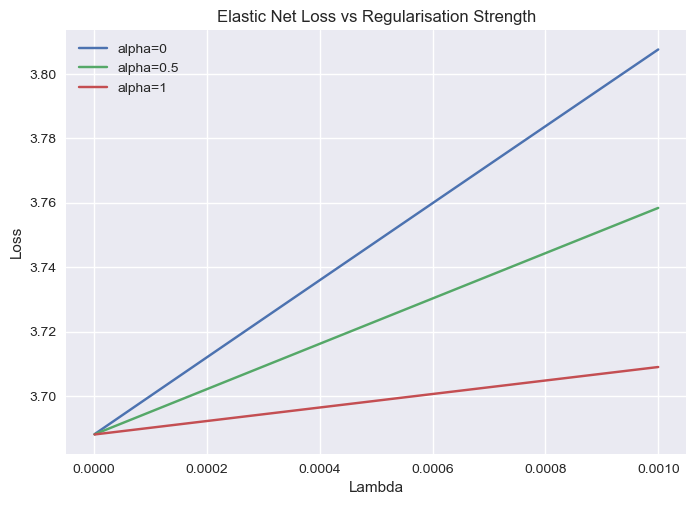

In [13]:
plt.figure()

for alpha in alphas:
    plt.plot(lambdas, results[alpha], label=f"alpha={alpha}")

plt.xlabel("Lambda")
plt.ylabel("Loss")
plt.title("Elastic Net Loss vs Regularisation Strength")
plt.legend()
plt.show()

## Support Vector Machine (SVM) Classification

In this task, we implement a **Support Vector Machine (SVM)** classifier from scratch to predict whether a mushroom is **poisonous or edible** based on its physical characteristics.

SVMs are supervised learning models that aim to find the optimal separating hyperplane between classes by maximising the margin between them.

We begin with a **linear soft-margin SVM**, which allows for some misclassification using a hinge loss function.


### Data Preparation

The dataset is split into input features $X$ and target labels $y$.
The labels are expected to be in ${-1, +1}$ for SVM classification.


In [15]:
mushroom_train = pd.read_csv("../data/mushrooms_train.csv")
mushroom_test = pd.read_csv("../data/mushrooms_test.csv")

train = mushroom_train.values
test = mushroom_test.values

X_train = train[:, :-1]
y_train = train[:, -1]

X_test = test[:, :-1]
y_test = test[:, -1]

### Hinge Loss Function

The SVM is trained using the **hinge loss**, defined as:

$$
\max(0, 1 - y_i (w^T x_i))
$$

This penalises points that are either misclassified or lie within the margin.

A regularisation term is added to control model complexity.


In [16]:
def compute_cost(w, X, y, regul_strength=1e5):
    distances = 1 - y * (X @ w)
    distances = np.maximum(0, distances)

    hinge_loss = regul_strength * np.mean(distances)

    return 0.5 * np.dot(w, w) + hinge_loss

### Gradient Computation

To optimise the SVM, we compute the gradient of the cost function.
This is used within a stochastic gradient descent (SGD) algorithm.


In [17]:
def compute_gradient(w, X, y, regul_strength=1e5):
    distances = 1 - y * (X @ w)
    dw = np.zeros_like(w)

    for i, d in enumerate(distances):
        if d > 0:
            dw += -regul_strength * y[i] * X[i]

    dw = dw / len(y) + w
    return dw

### Stochastic Gradient Descent

We use stochastic gradient descent (SGD) to iteratively update the model parameters.
At each step, the weights are adjusted in the direction that minimises the loss.


In [18]:
def sgd(X, y, lr=1e-5, iterations=1000, regul_strength=1e5):
    w = np.zeros(X.shape[1])

    for i in range(iterations):
        grad = compute_gradient(w, X, y, regul_strength)
        w -= lr * grad

    return w

### Adding Bias Term

To include an intercept in the model, we augment the feature matrix with a column of ones.


In [19]:
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

### Model Training and Evaluation

The trained model is evaluated using classification accuracy on both training and test datasets.


In [20]:
w = sgd(X_train, y_train)

def accuracy(w, X, y):
    preds = np.sign(X @ w)
    return np.mean(preds == y)

print("Training Accuracy:", accuracy(w, X_train, y_train))
print("Test Accuracy:", accuracy(w, X_test, y_test))

Training Accuracy: 0.4793205317577548
Test Accuracy: 0.48473658296405714


### Cross-Validation

To evaluate the robustness of the SVM model, we use **k-fold cross-validation**.

The dataset is split into $k$ folds. For each iteration:

* One fold is used for validation
* The remaining folds are used for training

This process provides a more reliable estimate of model performance and helps reduce overfitting.


In [21]:
def create_folds(X, y, k=4):
    indices = np.random.permutation(len(y))
    fold_sizes = len(y) // k

    folds = []
    for i in range(k):
        start = i * fold_sizes
        end = start + fold_sizes
        folds.append(indices[start:end])

    return folds

### Cross-Validation Evaluation

We train and evaluate the SVM across multiple folds, recording both training and validation accuracy.


In [22]:
def cross_validate(X, y, k=4):
    folds = create_folds(X, y, k)

    train_scores = []
    val_scores = []

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])

        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]

        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]

        # Add bias
        X_train_fold = np.hstack([X_train_fold, np.ones((X_train_fold.shape[0], 1))])
        X_val_fold = np.hstack([X_val_fold, np.ones((X_val_fold.shape[0], 1))])

        w = sgd(X_train_fold, y_train_fold)

        train_scores.append(accuracy(w, X_train_fold, y_train_fold))
        val_scores.append(accuracy(w, X_val_fold, y_val_fold))

    return train_scores, val_scores

In [23]:
train_scores, val_scores = cross_validate(X_train[:, :-1], y_train)

print("Training scores:", train_scores)
print("Validation scores:", val_scores)
print("Average validation accuracy:", np.mean(val_scores))

Training scores: [np.float64(0.47651888341543513), np.float64(0.48538587848932674), np.float64(0.4781609195402299), np.float64(0.4781609195402299)]
Validation scores: [np.float64(0.4886699507389163), np.float64(0.46206896551724136), np.float64(0.483743842364532), np.float64(0.483743842364532)]
Average validation accuracy: 0.4795566502463054


### Kernelised SVM

Linear SVMs may struggle when the data is not linearly separable.
To address this, we use **kernel methods**, which implicitly map the data into a higher-dimensional space.

Instead of computing dot products directly, we use a **kernel function**:

$$
K(x_i, x_j)
$$

This allows us to compute similarities between data points without explicitly transforming the data.

We explore two kernel functions:

* **Radial Basis Function (RBF) kernel**
* **Sigmoid kernel**


In [24]:
def rbf_kernel(X1, X2, gamma):
    n1 = X1.shape[0]
    n2 = X2.shape[0]

    K = np.zeros((n1, n2))

    for i in range(n1):
        diff = X2 - X1[i]
        K[i] = np.exp(-gamma * np.sum(diff**2, axis=1))

    return K

In [25]:
def sigmoid_kernel(X1, X2, gamma):
    return np.tanh(gamma * (X1 @ X2.T) + 1)

### Kernel SVM Loss Function

In the kernelised SVM, the model is expressed in terms of a vector $u$ and the kernel matrix $K$.

The loss function becomes:

$$
\frac{1}{2} u^T K u + \lambda \sum_{i=1}^{N} \max(0, 1 - y_i (K_i u))
$$

This replaces the direct dependence on input features with kernel evaluations.


In [26]:
def kernel_svm_loss(u, K, y, regul_strength=1):
    distances = 1 - y * (K @ u)
    distances = np.maximum(0, distances)

    hinge = regul_strength * np.mean(distances)

    return 0.5 * u @ (K @ u) + hinge

In [27]:
def kernel_gradient(u, K, y, regul_strength=1):
    distances = 1 - y * (K @ u)
    grad = np.zeros_like(u)

    for i, d in enumerate(distances):
        if d > 0:
            grad += -regul_strength * y[i] * K[i]

    grad = grad / len(y) + K @ u
    return grad

In [28]:
def kernel_sgd(K, y, lr=1e-4, iterations=1000, regul_strength=1):
    u = np.zeros(K.shape[1])

    for i in range(iterations):
        grad = kernel_gradient(u, K, y, regul_strength)
        u -= lr * grad

    return u

### Kernel Comparison

We evaluate different values of the kernel parameter $\gamma$ to observe how model performance changes.

In [29]:
gammas = [0.01, 0.1, 1, 2]

for gamma in gammas:
    print(f"\nGamma = {gamma}")

    K_rbf = rbf_kernel(X_train[:, :-1], X_train[:, :-1], gamma)
    u_rbf = kernel_sgd(K_rbf, y_train)

    train_acc = np.mean(np.sign(K_rbf @ u_rbf) == y_train)
    print("RBF Training Accuracy:", train_acc)

    K_sig = sigmoid_kernel(X_train[:, :-1], X_train[:, :-1], gamma)
    u_sig = kernel_sgd(K_sig, y_train)

    train_acc = np.mean(np.sign(K_sig @ u_sig) == y_train)
    print("Sigmoid Training Accuracy:", train_acc)


Gamma = 0.01
RBF Training Accuracy: 0.4793205317577548
Sigmoid Training Accuracy: 0.4793205317577548

Gamma = 0.1
RBF Training Accuracy: 0.4793205317577548
Sigmoid Training Accuracy: 0.4793205317577548

Gamma = 1
RBF Training Accuracy: 0.4793205317577548
Sigmoid Training Accuracy: 0.4793205317577548

Gamma = 2
RBF Training Accuracy: 0.4793205317577548
Sigmoid Training Accuracy: 0.4793205317577548


## Task 3: Neural Networks (MLP)

In this task, we implement a **Multi-Layer Perceptron (MLP)** to classify image data from the Fashion dataset.

Each image is:
- Grayscale
- Resolution: 28 × 28 pixels
- Flattened into a vector of length 784

The goal is to learn a mapping from pixel values to class labels using a deep feedforward neural network.

In [30]:
fashion_train = pd.read_csv("../data/fashion_train.csv")
fashion_test = pd.read_csv("../data/fashion_test.csv")

fash_train = np.array(fashion_train)[:, 2:]
fash_test = np.array(fashion_test)[:, 2:]

print(fash_train.shape)
print(fash_test.shape)

(10000, 784)
(4000, 784)


### Network Architecture

The MLP consists of multiple fully connected (dense) layers with ReLU activation functions.

Each layer performs:
- Linear transformation: `xW + b`
- Non-linearity: ReLU

Weights are initialised using **Glorot (Xavier) initialisation** to improve training stability.

In [31]:
def dense(x, W, b):
    return x @ W + b

def relu(h):
    return np.maximum(h, 0.)

In [32]:
# Glorot initialisation
def glorot_init(in_dim, out_dim):
    var = 2.0 / (in_dim + out_dim)
    return np.random.randn(in_dim, out_dim) * np.sqrt(var)

W0 = glorot_init(784, 256)
b0 = np.zeros(256)

W1 = glorot_init(256, 256)
b1 = np.zeros(256)

W2 = glorot_init(256, 256)
b2 = np.zeros(256)

W3 = glorot_init(256, 256)
b3 = np.zeros(256)

W4 = glorot_init(256, 10)
b4 = np.zeros(10)

In [33]:
def mlp(x):
    h = relu(dense(x, W0, b0))
    h = relu(dense(h, W1, b1))
    h = relu(dense(h, W2, b2))
    h = relu(dense(h, W3, b3))
    y = dense(h, W4, b4)
    return y

In [34]:
y_hat_train = mlp(fash_train)
y_hat_test = mlp(fash_test)

### Training Approach

A simplified gradient-based optimisation approach is used to update parameters.

Note:  
This implementation does not perform full backpropagation through all layers.  
Instead, a simplified optimisation is applied for demonstration purposes.

In [35]:
def mse_loss(x, y, beta0, beta):
    return 0.5 * ((y - beta0 - x @ beta)**2).mean()

def grad(x, y, beta0, beta):
    g = (y - beta0 - x @ beta)
    return -g.mean(axis=0), -(x.T[..., np.newaxis] * g).mean(axis=1)

### Training the Model

We train the model using different learning rates to analyse convergence behaviour.

The loss is recorded at each epoch to visualise training performance.

In [36]:
iterations = 40
learning_rate = 0.001

losses_1 = []
beta0 = np.zeros(1)

for i in range(iterations):
    x_batch = fash_train[i, :]
    y_batch = y_hat_train[i]

    beta = np.ones(x_batch.shape)

    loss = mse_loss(x_batch, y_batch, beta0, beta)
    losses_1.append(loss)

    beta0_grad, beta_grad = grad(x_batch, y_batch, beta0, beta)

    beta0 -= learning_rate * beta0_grad
    beta -= learning_rate * beta_grad

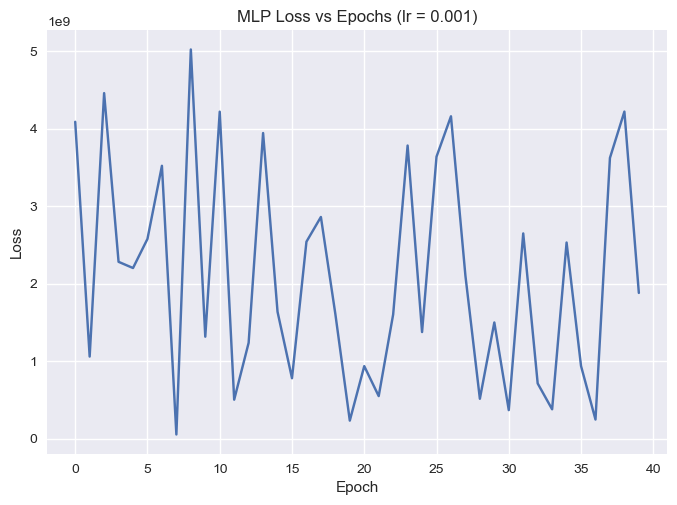

In [37]:
plt.plot(losses_1)
plt.title("MLP Loss vs Epochs (lr = 0.001)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

The loss curve shows unstable convergence, indicating that:
- The learning rate may not be optimal
- More epochs may be required

To investigate further, different learning rates are tested.

In [38]:
def train_mlp_lr(lr, iterations=80):
    losses = []
    beta0 = np.zeros(1)

    for i in range(iterations):
        x_batch = fash_train[i, :]
        y_batch = y_hat_train[i]

        beta = np.ones(x_batch.shape)

        loss = mse_loss(x_batch, y_batch, beta0, beta)
        losses.append(loss)

        beta0_grad, beta_grad = grad(x_batch, y_batch, beta0, beta)

        beta0 -= lr * beta0_grad
        beta -= lr * beta_grad

    return losses

In [39]:
losses_small = train_mlp_lr(0.00005)
losses_large = train_mlp_lr(0.1)

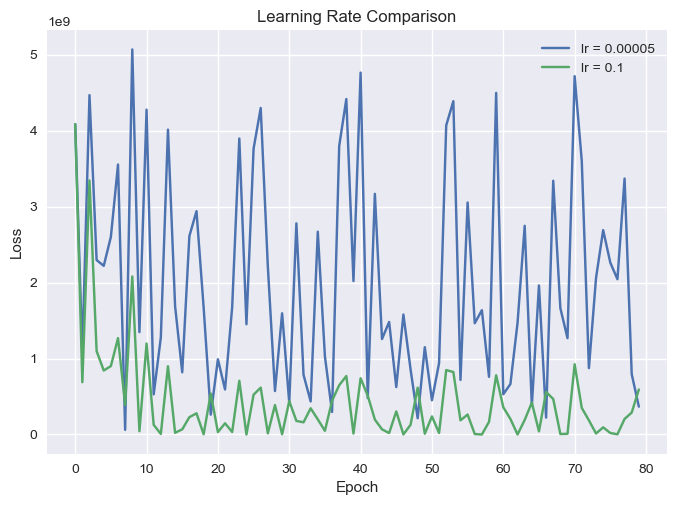

In [40]:
plt.plot(losses_small, label="lr = 0.00005")
plt.plot(losses_large, label="lr = 0.1")
plt.legend()
plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Results

- A very small learning rate leads to slow convergence
- A larger learning rate improves convergence speed significantly
- However, excessively large learning rates may lead to instability

### Final Insight

The choice of learning rate is critical in training neural networks, and must balance:
- Speed of convergence
- Stability of optimisation